# Example Notebook for Extracting Noise-Wave Parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from simulation.observation_handler import ObservationHandler
from gcr.data_processing import DataHandler
from astropy import units as un

In [2]:
simulated_data_handler = DataHandler(filepath='simulated_data/sim_data.hdf5',
                                     gamma_src_dict={'heated_load': 'simulated_data/heated_load_gamma_src.s2p',
                                                     'internal_load': 'simulated_data/internal_load_gamma_src.s2p',
                                                     'long_open': 'simulated_data/long_open_gamma_src.s2p',
                                                     'long_short': 'simulated_data/long_short_gamma_src.s2p',
                                                     'open': 'simulated_data/open_gamma_src.s2p',
                                                     'short': 'simulated_data/short_gamma_src.s2p',
                                                     'Test_src': 'simulated_data/Test_src_gamma_src.s2p'},
                                     gamma_rec='simulated_data/gamma_rec.s2p')

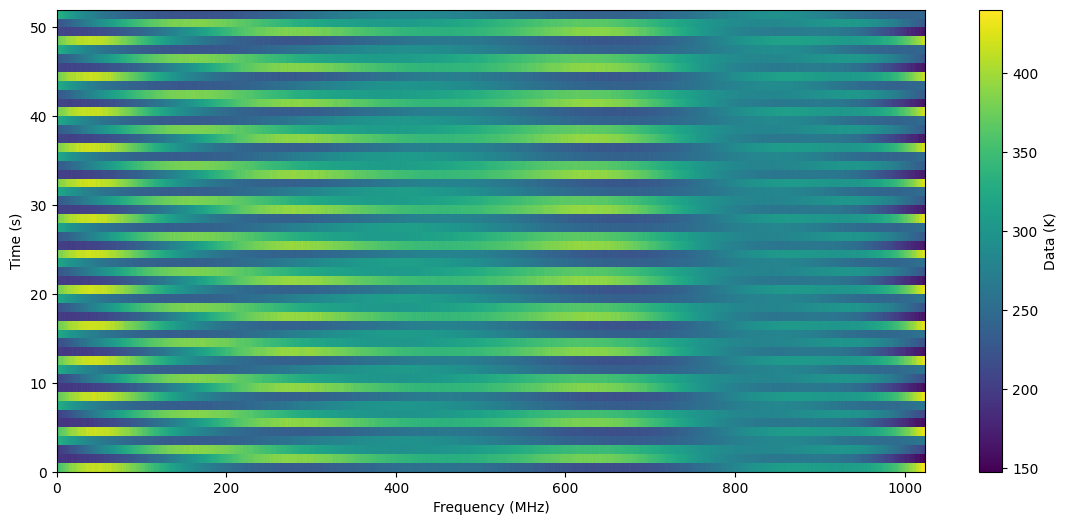

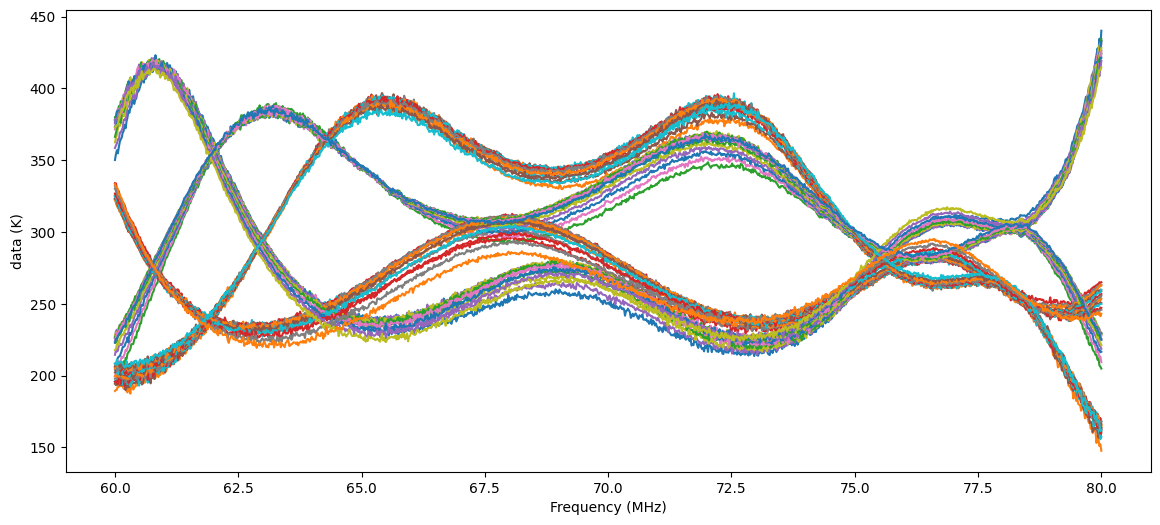

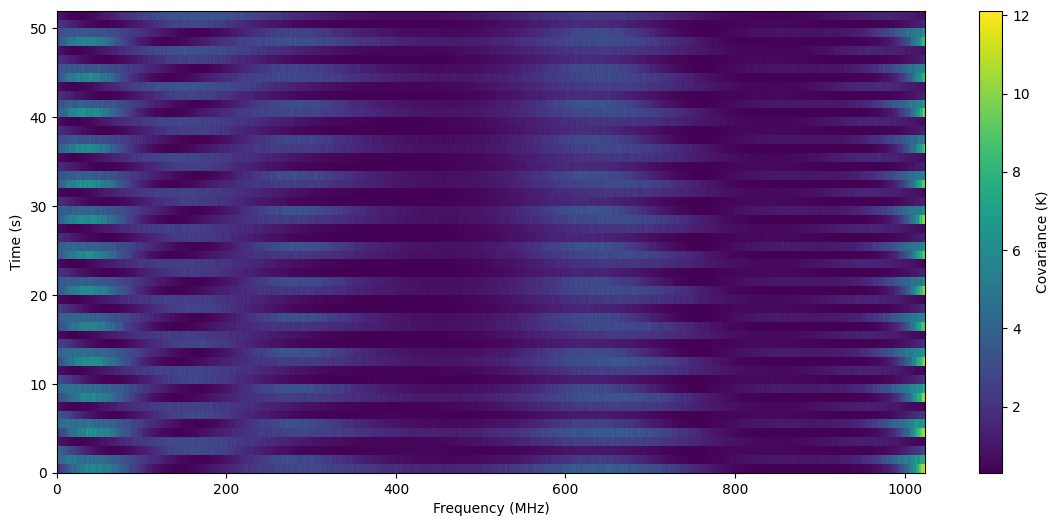

In [3]:
simulated_data_handler.produce_nw_fitting_data()


plt.pcolormesh(simulated_data_handler.data_waterfall)
plt.colorbar(label='Data (K)')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Time (s)')
plt.gcf().set_size_inches(14, 6)
plt.show()

for spectra in simulated_data_handler.data_waterfall:
    plt.plot(simulated_data_handler.freqs, spectra)
plt.xlabel('Frequency (MHz)')
plt.ylabel('data (K)')
plt.gcf().set_size_inches(14, 6)
plt.show()


plt.pcolormesh(simulated_data_handler.covariance_waterfall)
plt.colorbar(label='Covariance (K)')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Time (s)')
plt.gcf().set_size_inches(14, 6)
plt.show()

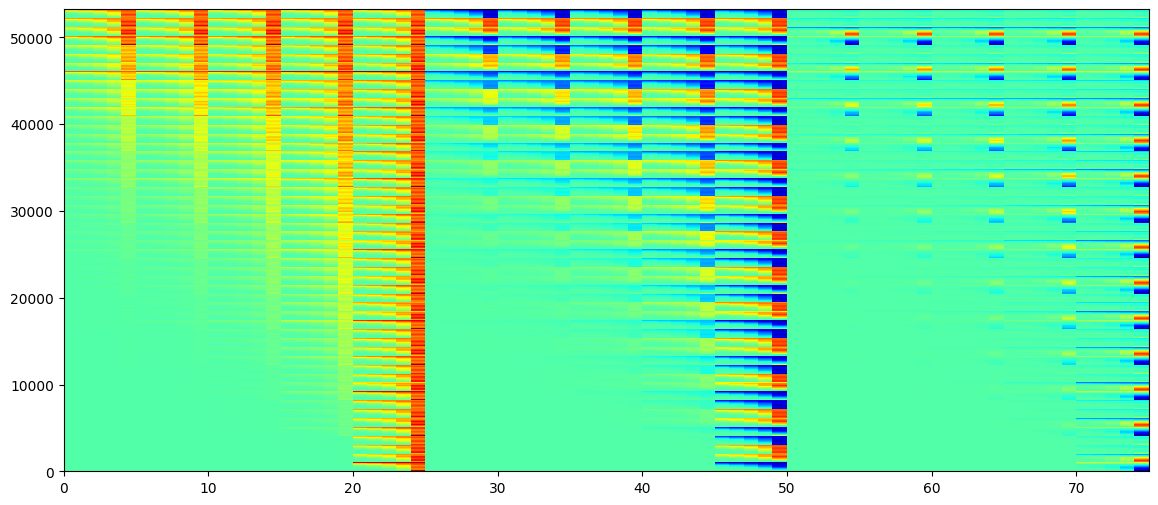

In [4]:
unc_coeffs_deg = (5,5)
cos_coeffs_deg = (5,5)
sin_coeffs_deg = (5,5)


simulated_data_handler.generate_transfer_matrix(unc_coeffs_deg=unc_coeffs_deg,
                                                cos_coeffs_deg=cos_coeffs_deg,
                                                sin_coeffs_deg=sin_coeffs_deg)

plt.pcolormesh(simulated_data_handler.transfer_matrix, cmap='jet')
plt.gcf().set_size_inches(14, 6)
plt.show()

n_t_unc_coeffs = unc_coeffs_deg[0]*unc_coeffs_deg[-1]
n_t_cos_coeffs = cos_coeffs_deg[0]*cos_coeffs_deg[-1]
n_t_sin_coeffs = sin_coeffs_deg[0]*sin_coeffs_deg[-1]



In [5]:
flattened_data = simulated_data_handler.data_waterfall.flatten()

t_vec = np.linalg.lstsq(simulated_data_handler.transfer_matrix, flattened_data)[0]

simulated_data_handler.covariance_waterfall *=1

t_vec_weiner_filter = simulated_data_handler.generate_nw_gcr_solution(weiner_filter=False, use_linsolv_start=False)

print(len(t_vec))
print(len(t_vec_weiner_filter))

75
75


In [6]:
from gcr.basis_construction import reconstruct_surface

t_unc_coeffs = t_vec_weiner_filter[:n_t_unc_coeffs]
t_cos_coeffs = t_vec_weiner_filter[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = t_vec_weiner_filter[n_t_unc_coeffs+n_t_cos_coeffs:]


t_unc_surface = reconstruct_surface(x=np.array(simulated_data_handler.freqs),
                                    y=np.array(simulated_data_handler.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=simulated_data_handler.freq_norm,
                                    y_array_norm_func=simulated_data_handler.time_norm)

t_cos_surface = reconstruct_surface(x=np.array(simulated_data_handler.freqs),
                                    y=np.array(simulated_data_handler.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=simulated_data_handler.freq_norm,
                                    y_array_norm_func=simulated_data_handler.time_norm)

t_sin_surface = reconstruct_surface(x=np.array(simulated_data_handler.freqs),
                                    y=np.array(simulated_data_handler.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=simulated_data_handler.freq_norm,
                                    y_array_norm_func=simulated_data_handler.time_norm)

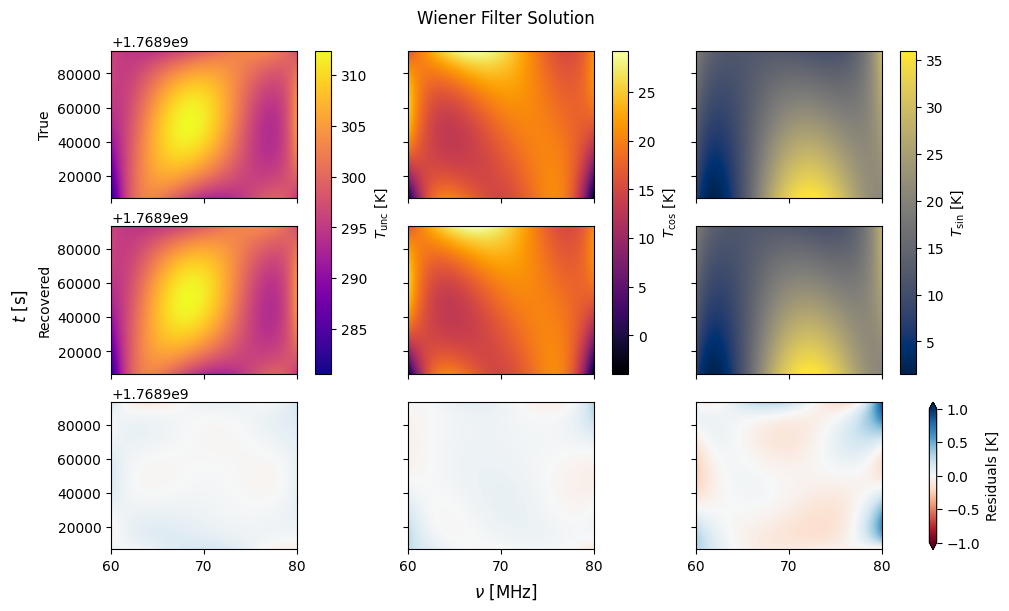

In [7]:
import h5py
with h5py.File('simulated_data/sim_data.hdf5_sim') as f:
    t_unc_sim = f['t_unc'][()]
    t_sin_sim = f['t_sin'][()]
    t_cos_sim = f['t_cos'][()]


# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)

resid_vminmax = 1

# resid_vminmax = np.max(np.abs(np.array([t_unc_sim - t_unc_surface,
#                                         t_cos_sim - t_cos_surface,
#                                         t_sin_sim - t_sin_surface])))

unc = axes[0,0].pcolormesh(np.array(simulated_data_handler.freqs),
                     np.array(simulated_data_handler.times),
                     t_unc_sim,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(simulated_data_handler.freqs),
                     np.array(simulated_data_handler.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(simulated_data_handler.freqs),
                     np.array(simulated_data_handler.times),
                     t_unc_sim - t_unc_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(simulated_data_handler.freqs),
                     np.array(simulated_data_handler.times),
                     t_cos_sim,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(simulated_data_handler.freqs),
                     np.array(simulated_data_handler.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(simulated_data_handler.freqs),
                     np.array(simulated_data_handler.times),
                     t_cos_sim - t_cos_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(simulated_data_handler.freqs),
                     np.array(simulated_data_handler.times),
                     t_sin_sim,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(simulated_data_handler.freqs),
                     np.array(simulated_data_handler.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(simulated_data_handler.freqs),
                     np.array(simulated_data_handler.times),
                     t_sin_sim - t_sin_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]',
             extend='both')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Wiener Filter Solution')
plt.gcf().set_size_inches(10., 6.)
plt.show()

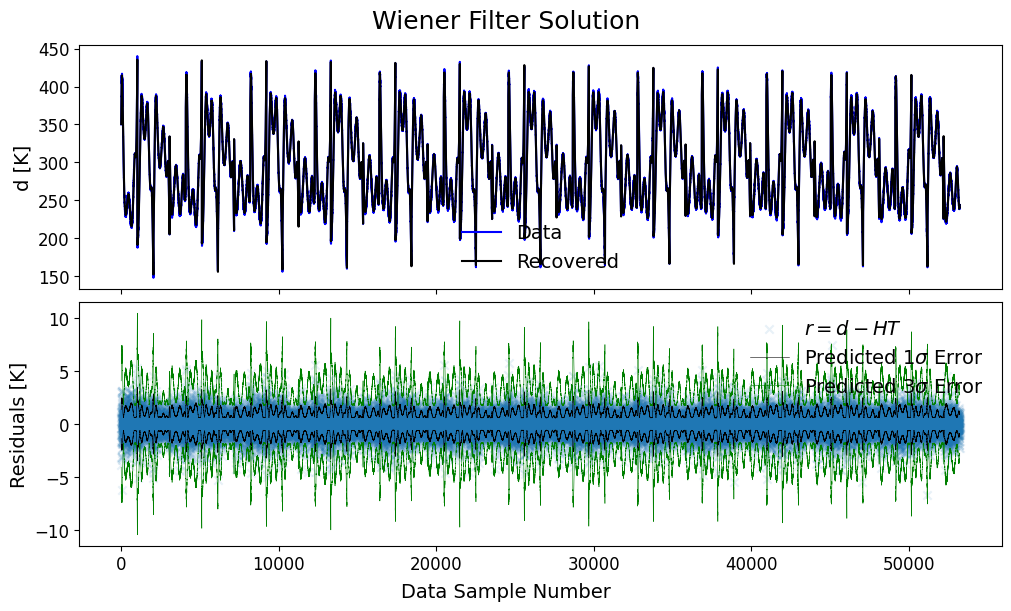

In [8]:
recovered_dw = simulated_data_handler.transfer_matrix @ t_vec_weiner_filter


fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, layout='constrained')
ax1.plot(simulated_data_handler.data_waterfall.flatten(), label='Data', c='blue')
ax1.plot(recovered_dw, label='Recovered', c='black')
ax1.legend(frameon=False, fontsize=14)
ax1.set_ylabel('d [K]', fontsize=14)
ax1.tick_params('both', labelsize=12)
ax2.scatter(np.arange(len(simulated_data_handler.data_waterfall.flatten())), simulated_data_handler.data_waterfall.flatten() - recovered_dw, marker='x',alpha=0.1,
            label=r'$r = d - HT$')
ax2.set_ylabel('Residuals [K]', fontsize=14)
ax2.plot(np.sqrt(simulated_data_handler.covariance_waterfall.flatten()), 'k-', lw=0.4)
ax2.plot(-np.sqrt(simulated_data_handler.covariance_waterfall.flatten()), 'k-', label=r'Predicted $1\sigma$ Error', lw=0.4)

ax2.plot(3*np.sqrt(simulated_data_handler.covariance_waterfall.flatten()), 'g-', lw=0.4)
ax2.plot(-3*np.sqrt(simulated_data_handler.covariance_waterfall.flatten()), 'g-', label=r'Predicted $3\sigma$ Error', lw=0.4)
ax2.tick_params('both', labelsize=12)
ax2.legend(fontsize=14, frameon=False)
fig.supxlabel('Data Sample Number', fontsize=14)
fig.suptitle('Wiener Filter Solution', fontsize=18)
plt.gcf().set_size_inches(10., 6.)
plt.show()

In [9]:
from gcr.transfer_matrix_construction import construct_src_transfer_matrix

# print(simulated_data_handler.freqs.value)
# print(simulated_data_handler.times.value)

# src_transfer_matrix = construct_src_transfer_matrix(simulated_data_handler.freqs.value,
#                                                     time_array=simulated_data_handler.times[:].value,
#                                                     freq_norm_func=simulated_data_handler.freq_norm,
#                                                     time_norm_func=simulated_data_handler.time_norm,
#                                                     unc_poly_orders=unc_coeffs_deg,
#                                                     cos_poly_orders=cos_coeffs_deg,
#                                                     sin_poly_orders=sin_coeffs_deg,
#                                                     gamma_rec=simulated_data_handler.gamma_rec,
#                                                     gamma_src_label='Test_src',
#                                                     switch_state_src_gamma_dict=simulated_data_handler.gamma_src_dict)

# h_src_T_nw = src_transfer_matrix @ t_vec

# print(simulated_data_handler.data_waterfall.shape)

# h_src_T_nw = h_src_T_nw.reshape((int(len(h_src_T_nw) / len(simulated_data_handler.freqs)), len(simulated_data_handler.freqs)))

# plt.pcolormesh(h_src_T_nw)
# plt.colorbar()
# plt.show()

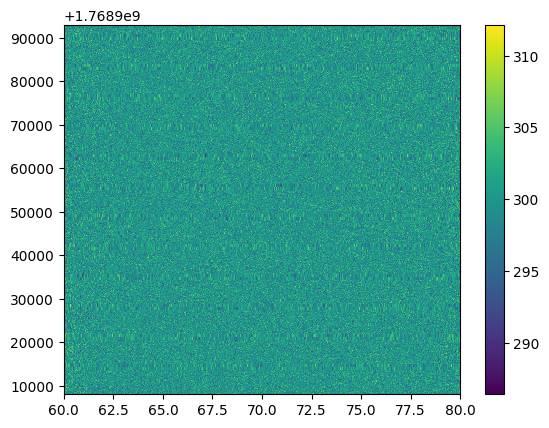

In [10]:
from gcr.source_recovery import recover_source_temperatures

t_src_waterfall, t_src_cov, source_times = recover_source_temperatures(simulated_data_handler.waterfall,
                                                                       simulated_data_handler.times.value,
                                                                       simulated_data_handler.freqs.value,
                                                                       switch_times=simulated_data_handler.switch_times,
                                                                       switch_states=simulated_data_handler.switch_states,
                                                                       source_temperatures=simulated_data_handler.temperature_dict,
                                                                       temperatures_times=simulated_data_handler.temperature_times,
                                                                       t_nw_vector=t_vec_weiner_filter,
                                                                       gamma_rec=simulated_data_handler.gamma_rec,
                                                                       gamma_src_dict=simulated_data_handler.gamma_src_dict,
                                                                       internal_load_label='internal_load',
                                                                       noise_source_label='heated_load',
                                                                       freq_norm_func=simulated_data_handler.freq_norm,
                                                                       time_norm_func=simulated_data_handler.time_norm,
                                                                       unc_poly_orders=unc_coeffs_deg,
                                                                       cos_poly_orders=cos_coeffs_deg,
                                                                       sin_poly_orders=sin_coeffs_deg,
                                                                       t_src_label='Test_src')


plt.pcolormesh(simulated_data_handler.freqs.value,
               source_times,
               t_src_waterfall)
plt.colorbar()

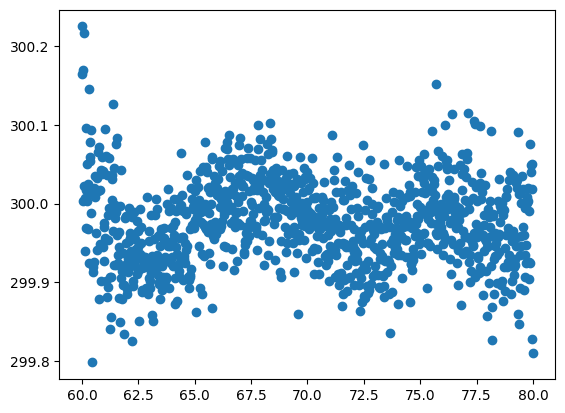

299.97448100975544
0.054856409930084137


In [11]:
plt.scatter(simulated_data_handler.freqs, t_src_waterfall.mean(axis=0))
plt.show()

print(t_src_waterfall.mean(axis=0).mean())
print(t_src_waterfall.mean(axis=0).std())


In [12]:
def iterative_polynomial_search(data_handler_obj:DataHandler,
                                max_iter:int = 20):
    n_deg = 1
    unc_coeffs_deg = (n_deg, n_deg)
    cos_coeffs_deg = (n_deg, n_deg)
    sin_coeffs_deg = (n_deg, n_deg)

    data_handler_obj.generate_transfer_matrix(unc_coeffs_deg, cos_coeffs_deg, sin_coeffs_deg)

    t_vec = np.linalg.lstsq(data_handler_obj.transfer_matrix,
                            data_handler_obj.data_waterfall.flatten())[0]
    
    current_resid = np.median(np.abs((data_handler_obj.transfer_matrix @ t_vec) - data_handler_obj.data_waterfall.flatten()))
    print(current_resid)
    loop_bool = True

    while loop_bool:
        if n_deg > max_iter:
            break
        loop_n_deg = n_deg + 1
        unc_coeffs_deg = (loop_n_deg, loop_n_deg)
        cos_coeffs_deg = (loop_n_deg, loop_n_deg)
        sin_coeffs_deg = (loop_n_deg, loop_n_deg)

        data_handler_obj.generate_transfer_matrix(unc_coeffs_deg, cos_coeffs_deg, sin_coeffs_deg)

        t_vec = np.linalg.lstsq(data_handler_obj.transfer_matrix,
                                data_handler_obj.data_waterfall.flatten())[0]
        
        loop_resid = np.median(np.abs((data_handler_obj.transfer_matrix @ t_vec) - data_handler_obj.data_waterfall.flatten()))

        if loop_resid < current_resid:
            n_deg = loop_n_deg
            current_resid = loop_resid
        elif loop_resid > current_resid:
            loop_bool = False

    return n_deg

# iterative_polynomial_search(data_handler_obj=simulated_data_handler)
    

In [13]:
def compute_residual(DataHandler_obj:DataHandler,
                     unc_freq,
                     unc_time,
                     cos_freq,
                     cos_time,
                     sin_freq,
                     sin_time):
    # unc_freq = int(unc_freq)
    # unc_time = int(unc_time)
    # cos_freq = int(cos_freq)
    # cos_freq = int(cos_freq)
    # sin_freq = int(sin_freq)
    # sin_time = int(sin_time)
    
    DataHandler_obj.generate_transfer_matrix(unc_coeffs_deg=(unc_freq, unc_time),
                                             cos_coeffs_deg=(cos_freq, cos_time),
                                             sin_coeffs_deg=(sin_freq, sin_time))
    t_vec = np.linalg.lstsq(DataHandler_obj.transfer_matrix,
                            DataHandler_obj.data_waterfall.flatten())[0]
    
    current_resid = np.median(np.abs((DataHandler_obj.transfer_matrix @ t_vec) - DataHandler_obj.data_waterfall.flatten()))

    return current_resid



In [14]:
def opt_finder(data_handler_obj:DataHandler,
               n_deg_start:int):
    unc_freq_range = np.arange(n_deg_start - 1, n_deg_start + 2)
    unc_time_range = np.arange(n_deg_start - 1, n_deg_start + 2)
    cos_freq_range = np.arange(n_deg_start - 1, n_deg_start + 2)
    cos_time_range = np.arange(n_deg_start - 1, n_deg_start + 2)
    sin_freq_range = np.arange(n_deg_start - 1, n_deg_start + 2)
    sin_time_range = np.arange(n_deg_start - 1, n_deg_start + 2)

    ufv, utv, cfv, ctv, sfv, stv = np.meshgrid(unc_freq_range, unc_time_range, cos_freq_range, cos_time_range, sin_freq_range, sin_time_range)

    r_med = np.ones(shape=ufv.shape)

    r_med = compute_residual(data_handler_obj, ufv, utv, cfv, ctv, sfv, stv)

    min_resid = np.argmin(r_med)

    return ufv[min_resid], utv[min_resid], cfv[min_resid], ctv[min_resid], sfv[min_resid], stv[min_resid]
# opt_finder(simulated_data_handler, 5)

In [15]:
# from gcr.basis_construction import build_cosine_product_basis, reconstruct_cosine_product


# B = build_cosine_product_basis(x=simulated_data_handler.freqs.value, n_m=10,
#                        y=simulated_data_handler.times.value, n_n=10,
#                        Lx=40,
#                        Ly=3600*24*4)


# coeffs, *_ = np.linalg.lstsq(B, t_unc_surface.flatten())[0]
# print(coeffs)
# t_unc_reconstruct = reconstruct_cosine_product(x=simulated_data_handler.freqs.value,
#                        y=simulated_data_handler.times.value,
#                        Lx=40,
#                        Ly=3600*24*4,
#                        coeffs=coeffs)



# plt.pcolormesh(simulated_data_handler.freqs.value,
#                simulated_data_handler.times.value,
#                t_unc_surface)
# plt.colorbar()
# plt.show()

# plt.pcolormesh(simulated_data_handler.freqs.value,
#                simulated_data_handler.times.value,
#                t_unc_reconstruct)
# plt.colorbar()
# plt.show()

In [16]:
simulated_data_handler.generate_gcr_solutions_mulitprocess(n_gcr_sol=1000)

print('Done')

print(simulated_data_handler.gcr_solutions)

0
23
46
69
92
115
138
161
184
207
230
253
276
299
322
345
368
391
414
437
460
483
506
529
552
575
598
621
644
667
690
713
736
759
805
782
828
851
874
897
920
943
966
989


Process SpawnPoolWorker-52:
Process SpawnPoolWorker-47:
Process SpawnPoolWorker-51:
Process SpawnPoolWorker-54:
Process SpawnPoolWorker-48:
Process SpawnPoolWorker-45:
Process SpawnPoolWorker-49:
Process SpawnPoolWorker-50:
Process SpawnPoolWorker-55:
Process SpawnPoolWorker-53:
Process SpawnPoolWorker-46:


KeyboardInterrupt: 

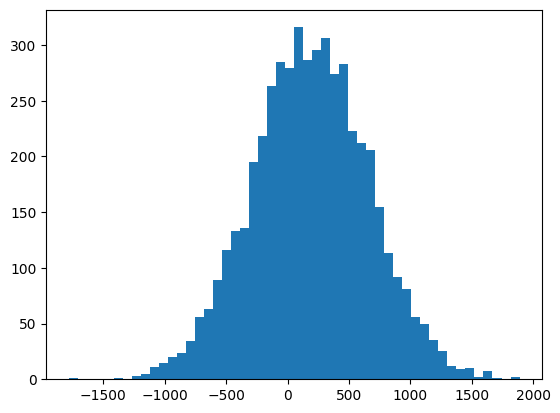

In [ ]:
gcr_sol = np.array(simulated_data_handler.gcr_solutions)

import corner

plt.hist(gcr_sol[:,1], bins=50)
plt.show()
# corner.corner(gcr_sol)
# plt.show()